<a href="https://colab.research.google.com/github/USUARIO/REPOSITORIO/blob/main/Taller07_KNN_RNN_digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 07 — Clasificadores KNN y RNN sobre el dataset `digits`

**Inteligencia Artificial — ELP 8012 — Universidad del Norte**
Programa de Ingeniería de Sistemas · Profesor: Eduardo Zurek, Ph.D.

| Integrante | Código |
|---|---|
| Maria Ordoñez | 200169828 |
| Jhonayker Echeverria | 200181127 |
| Franklin Amador | 200180542 |

---

## Objetivo

Diseñar, implementar y evaluar dos clasificadores basados en vecindad para reconocer dígitos escritos a mano del dataset `digits` de scikit-learn:

- **KNN (K vecinos más cercanos)** — `KNeighborsClassifier`: la clase se decide por votación entre los **K** ejemplos de entrenamiento más cercanos.
- **RNN (vecinos dentro de un radio)** — `RadiusNeighborsClassifier`: la clase se decide por votación entre **todos** los ejemplos de entrenamiento que están a una distancia menor o igual a un radio **R**.

> **Nota sobre la sigla.**  *RNN* significa *Radius Nearest Neighbors*.

## 1. Librerías y configuración

Se fija una semilla (`SEMILLA = 42`) para que la partición y la validación cruzada sean reproducibles: al volver a ejecutar el cuaderno se obtienen los mismos números. **No se silencian las advertencias**: si algo sale mal, es mejor verlo.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

from sklearn.datasets import load_digits
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV)
from sklearn.neighbors import (KNeighborsClassifier, RadiusNeighborsClassifier,
                               NearestNeighbors)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, make_scorer, classification_report,
                             ConfusionMatrixDisplay)

SEMILLA = 42            # reproducibilidad
N_FOLDS = 4             # K-fold = 4 (requisito del enunciado)
TAMANO_PRUEBA = 0.20    # 80 % entrenamiento / 20 % prueba (requisito del enunciado)

# Carpeta donde se guardan las figuras (útil para el README del repositorio)
os.makedirs("figuras", exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 4)

print(f"Python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")

Python       3.11.15
numpy        2.4.4
pandas       3.0.2
matplotlib   3.10.9
scikit-learn 1.8.0


## 2. Carga y exploración del dataset `digits`

`load_digits()` contiene **1797** imágenes de dígitos (0 a 9) de **8 × 8 píxeles**. Cada píxel es un entero entre **0 y 16** que indica la intensidad del trazo. Al aplanar cada imagen se obtiene un vector de **64 características**, que es la representación que usan KNN y RNN para medir distancias.

In [2]:
digits = load_digits()
X = digits.data      # (n_muestras, 64) — cada fila es una imagen aplanada
y = digits.target    # (n_muestras,)   — dígito real 0..9

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Clases:", np.unique(y))
print("Rango de valores de los píxeles:", X.min(), "a", X.max())

Dimensiones de X: (1797, 64)
Dimensiones de y: (1797,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de valores de los píxeles: 0.0 a 16.0


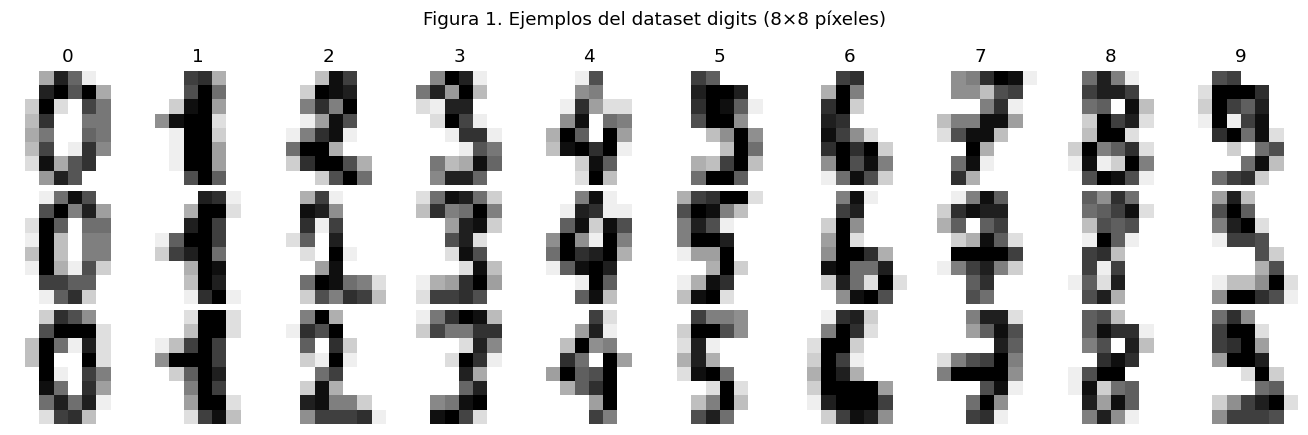

In [3]:
# Figura 1. Algunos ejemplos de cada dígito
fig, axes = plt.subplots(3, 10, figsize=(12, 4))
for digito in range(10):
    indices = np.where(y == digito)[0][:3]
    for fila, idx in enumerate(indices):
        ax = axes[fila, digito]
        ax.imshow(digits.images[idx], cmap="gray_r", interpolation="nearest")
        ax.axis("off")
        if fila == 0:
            ax.set_title(str(digito))
fig.suptitle("Figura 1. Ejemplos del dataset digits (8×8 píxeles)")
fig.tight_layout()
fig.savefig("figuras/fig1_ejemplos_digits.png", bbox_inches="tight")
plt.show()

In [4]:
# Distribución de clases: ¿está balanceado el dataset?
conteo = pd.Series(y).value_counts().sort_index()
display(conteo.rename("Muestras por clase").to_frame().T)
print(f"Mínimo: {conteo.min()}  |  Máximo: {conteo.max()}")

,0,1,2,3,4,5,6,7,8,9
Muestras por clase,178,182,177,183,181,182,181,179,174,180


Mínimo: 174  |  Máximo: 183


**Observaciones:**

- Las 10 clases están **prácticamente balanceadas** (entre 174 y 183 imágenes cada una), así que el *accuracy* es una métrica representativa y los promedios *macro* de precisión, recall y F1 no se distorsionan por clases minoritarias.
- **No se estandarizan las características.** Los 64 píxeles están en la misma unidad y escala (0–16), así que ninguno domina la distancia por tener un rango mayor. Esto es distinto del ejemplo de estatura/peso visto en clase, donde las escalas diferían en dos órdenes de magnitud. Además, `StandardScaler` dividiría por la desviación estándar de píxeles del borde que casi siempre valen 0, y así amplificaría ruido. En el anexo A se comprueba esto con datos.
- Se usa la **distancia euclidiana** (Minkowski con p = 2), la misma de los ejemplos del curso para variables numéricas continuas.

## 3. División 80 % entrenamiento / 20 % prueba

Se usa `train_test_split` con `test_size=0.20` (**requisito 2**). El parámetro `stratify=y` conserva la proporción de cada dígito en ambos subconjuntos.

El **conjunto de prueba se aparta desde ahora y no se usa para elegir K ni R.** Si se usara para elegir los hiperparámetros, la evaluación final sería optimista (fuga de información).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TAMANO_PRUEBA,
    random_state=SEMILLA,
    stratify=y,
)

print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X):.0%})")
print(f"Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X):.0%})")

display(pd.DataFrame({
    "Entrenamiento": pd.Series(y_train).value_counts().sort_index(),
    "Prueba": pd.Series(y_test).value_counts().sort_index(),
}).T)

Entrenamiento: 1437 muestras (80%)
Prueba:        360 muestras (20%)


,0,1,2,3,4,5,6,7,8,9
Entrenamiento,142,146,142,146,145,145,145,143,139,144
Prueba,36,36,35,37,36,37,36,36,35,36


## 4. Validación cruzada K-fold = 4 y métricas de desempeño

### 4.1 Validación cruzada

Para elegir K y R **solo se usa el 80 % de entrenamiento**, dividido en **4 folds** (**requisito 3**). Para cada valor candidato del hiperparámetro:

1. Se entrena con 3 folds (≈ 1078 imágenes) y se valida con el fold restante (≈ 359 imágenes).
2. Se repite 4 veces, rotando el fold de validación.
3. Se reporta la **media** y la **desviación estándar** de cada métrica sobre los 4 folds.

Se usa `StratifiedKFold` (cada fold conserva la proporción de clases) con `shuffle=True` y una semilla fija. Así **todos los valores de K y R se evalúan exactamente con las mismas 4 particiones**, y la comparación es justa.

### 4.2 Métricas

Es un problema **multiclase (10 clases)**, así que precisión, recall y F1 se calculan por clase y se promedian con **promedio macro** (todas las clases pesan igual):

| Métrica | Definición | Interpretación |
|---|---|---|
| Accuracy | $\frac{\text{aciertos}}{\text{total}}$ | Proporción global de dígitos bien clasificados |
| Precisión macro | $\frac{1}{10}\sum_c \frac{TP_c}{TP_c+FP_c}$ | Cuando el modelo dice "es un *c*", ¿qué tan seguido acierta? |
| Recall macro | $\frac{1}{10}\sum_c \frac{TP_c}{TP_c+FN_c}$ | De los *c* reales, ¿cuántos encuentra? |
| F1 macro | $\frac{1}{10}\sum_c \frac{2\,P_c R_c}{P_c+R_c}$ | Media armónica de precisión y recall |

**Criterio de selección** (el mismo para K y para R): se elige el valor con el **mayor F1 macro medio en validación cruzada**, porque resume precisión y recall en un solo número. Si hay empate, se desempata por mayor *accuracy*. Después se verifica si las cuatro métricas coinciden en el mismo ganador.

In [6]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA)

# zero_division=0 evita advertencias cuando, con radios muy pequeños, alguna clase
# nunca es predicha (su precisión se toma como 0, lo cual penaliza correctamente).
METRICAS = {
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="macro", zero_division=0),
    "recall":    make_scorer(recall_score,    average="macro", zero_division=0),
    "f1":        make_scorer(f1_score,        average="macro", zero_division=0),
}
NOMBRES = {"accuracy": "Accuracy", "precision": "Precisión macro",
           "recall": "Recall macro", "f1": "F1 macro"}

# Tamaño de cada fold, para verificar
for i, (idx_tr, idx_val) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"Fold {i}: entrenamiento={len(idx_tr)}, validación={len(idx_val)}")

Fold 1: entrenamiento=1077, validación=360
Fold 2: entrenamiento=1078, validación=359
Fold 3: entrenamiento=1078, validación=359
Fold 4: entrenamiento=1078, validación=359


### 4.3 Funciones auxiliares

Para no repetir código entre KNN y RNN, se definen tres funciones:

- `barrido_cv`: evalúa con validación cruzada una lista de valores del hiperparámetro y devuelve una tabla con media y desviación estándar de cada métrica.
- `seleccionar_mejor`: aplica el criterio de selección descrito arriba.
- `mejor_por_metrica`: indica qué valor ganaría según cada métrica por separado, para ver si coinciden.

In [7]:
def barrido_cv(crear_modelo, valores, nombre_param, scoring=METRICAS,
               train_score=False):
    # Evalúa crear_modelo(v) para cada v en `valores` con validación cruzada
    # (siempre con los mismos 4 folds). Devuelve un DataFrame con una fila por
    # valor y columnas <métrica>_media / <métrica>_std.
    filas = []
    for v in valores:
        res = cross_validate(crear_modelo(v), X_train, y_train, cv=cv,
                             scoring=scoring, return_train_score=train_score,
                             n_jobs=-1)
        fila = {nombre_param: v}
        for m in scoring:
            fila[f"{m}_media"] = res[f"test_{m}"].mean()
            fila[f"{m}_std"] = res[f"test_{m}"].std()
            if train_score:
                fila[f"{m}_train"] = res[f"train_{m}"].mean()
        filas.append(fila)
    return pd.DataFrame(filas)


def seleccionar_mejor(df, nombre_param):
    # Criterio: mayor F1 macro medio; desempate: mayor accuracy medio.
    orden = df.sort_values(["f1_media", "accuracy_media"], ascending=False)
    return orden.iloc[0]


def mejor_por_metrica(df, nombre_param):
    # Valor ganador según cada métrica individual (idxmax devuelve el primero si hay empate).
    return pd.DataFrame({
        NOMBRES[m]: {nombre_param: df.loc[df[f"{m}_media"].idxmax(), nombre_param],
                     "Valor (media CV)": df[f"{m}_media"].max()}
        for m in METRICAS
    }).T

## 5. Clasificador KNN

### ¿Cómo funciona?

Para clasificar una imagen nueva $x$:

1. Se calcula la distancia euclidiana $d(x, x_i) = \sqrt{\sum_{j=1}^{64}(x_j - x_{ij})^2}$ a cada imagen de entrenamiento.
2. Se toman los **K** ejemplos más cercanos.
3. Se asigna la clase más votada entre esos K vecinos (`weights="uniform"`: cada vecino vale un voto).

KNN no tiene una fase de entrenamiento propiamente dicha: `fit` solo memoriza los datos de referencia. **K** controla el compromiso sesgo–varianza:

- **K pequeño** → frontera muy flexible, sensible al ruido (posible sobreajuste).
- **K grande** → frontera suave, pero los vecinos incluyen ejemplos de otras clases (subajuste).

### 5.1 Rango de valores de K

Se evalúa **K = 1, 2, …, 30** (**requisito 4**). El límite de 30 es suficiente: cada clase tiene ≈ 108 ejemplos por fold de entrenamiento, y como se verá en la figura, desde K ≈ 10 el desempeño solo baja. Se incluyen valores pares e impares; con K par puede haber empates en la votación, que scikit-learn resuelve eligiendo la clase de menor índice.

In [8]:
valores_k = list(range(1, 31))

def crear_knn(k):
    return KNeighborsClassifier(
        n_neighbors=k,        # número de vecinos (hiperparámetro a seleccionar)
        weights="uniform",    # cada vecino vale un voto
        algorithm="auto",     # sklearn elige la estructura de búsqueda más eficiente
        metric="minkowski",
        p=2,                  # p=2 → distancia euclidiana
    )

df_k = barrido_cv(crear_knn, valores_k, "K", train_score=True)

tabla_k = df_k[["K"] + [f"{m}_media" for m in METRICAS] + [f"{m}_std" for m in METRICAS]]
display(tabla_k.round(4))

,K,accuracy_media,precision_media,recall_media,f1_media,accuracy_std,precision_std,recall_std,f1_std
0,1,0.9896,0.9899,0.9895,0.9895,0.0036,0.0034,0.0036,0.0036
1,2,0.9819,0.9829,0.9818,0.9817,0.0080,0.0073,0.0081,0.0082
2,3,0.9861,0.9866,0.9860,0.9861,0.0044,0.0041,0.0044,0.0044
3,4,0.9798,0.9808,0.9797,0.9797,0.0053,0.0048,0.0054,0.0053
4,5,0.9826,0.9833,0.9824,0.9825,0.0046,0.0041,0.0046,0.0045
5,6,0.9805,0.9813,0.9803,0.9804,0.0034,0.0031,0.0034,0.0034
6,7,0.9812,0.9819,0.9810,0.9811,0.0041,0.0038,0.0041,0.0041
7,8,0.9798,0.9805,0.9796,0.9796,0.0012,0.0010,0.0012,0.0012
8,9,0.9791,0.9797,0.9789,0.9789,0.0014,0.0014,0.0014,0.0014
9,10,0.9805,0.9813,0.9803,0.9804,0.0020,0.0017,0.0020,0.0020


### 5.2 Figura: métricas de desempeño en función de K

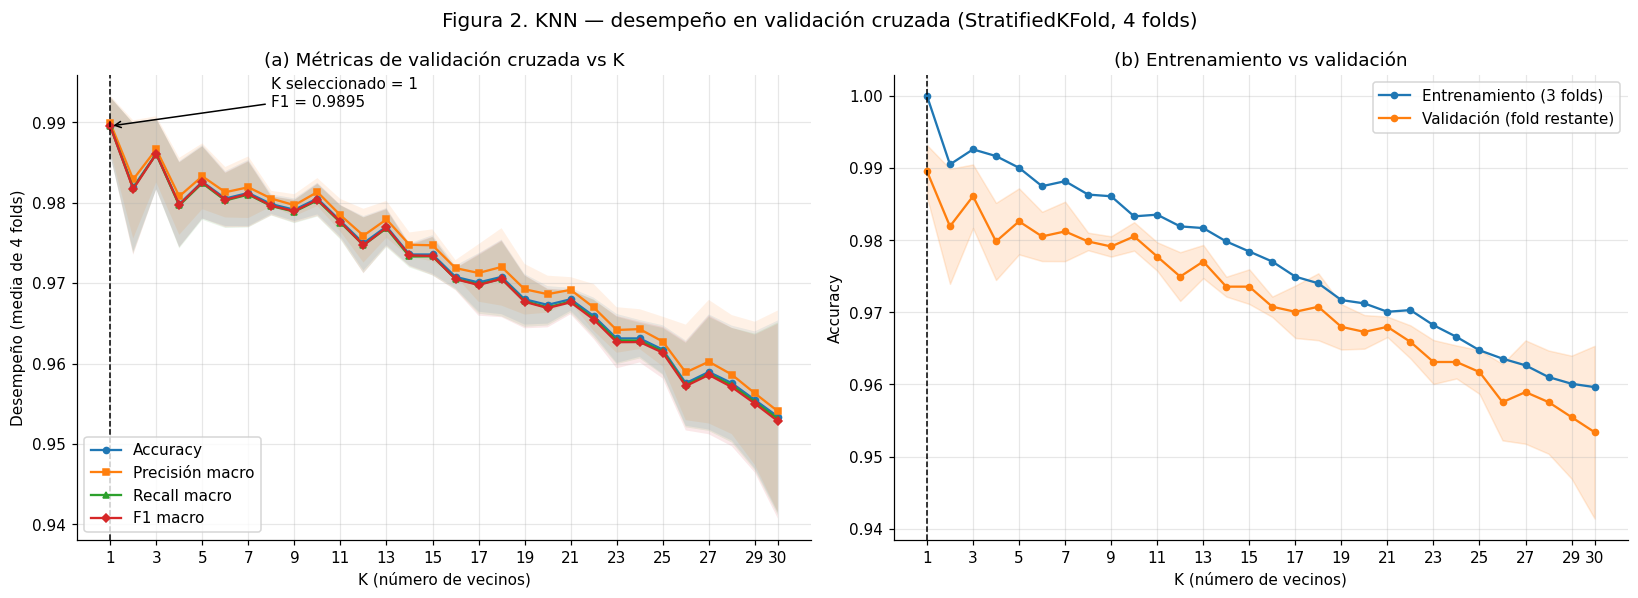

In [9]:
mejor_fila_k = seleccionar_mejor(df_k, "K")
mejor_k = int(mejor_fila_k["K"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Las 4 métricas en validación cruzada, con banda de ±1 desviación estándar
marcadores = {"accuracy": "o", "precision": "s", "recall": "^", "f1": "D"}
for m in METRICAS:
    media, std = df_k[f"{m}_media"], df_k[f"{m}_std"]
    ax1.plot(df_k["K"], media, marker=marcadores[m], ms=4, label=NOMBRES[m])
    ax1.fill_between(df_k["K"], media - std, media + std, alpha=0.10)
ax1.axvline(mejor_k, color="k", ls="--", lw=1)
ax1.annotate(f"K seleccionado = {mejor_k}\nF1 = {mejor_fila_k['f1_media']:.4f}",
             xy=(mejor_k, mejor_fila_k["f1_media"]), xytext=(8, 0.992),
             arrowprops=dict(arrowstyle="->"))
ax1.set(xlabel="K (número de vecinos)", ylabel="Desempeño (media de 4 folds)",
        title="(a) Métricas de validación cruzada vs K", xticks=valores_k[::2] + [30])
ax1.legend(loc="lower left")

# (b) Accuracy en entrenamiento vs validación: sobreajuste / subajuste
ax2.plot(df_k["K"], df_k["accuracy_train"], "o-", ms=4, label="Entrenamiento (3 folds)")
ax2.plot(df_k["K"], df_k["accuracy_media"], "o-", ms=4, label="Validación (fold restante)")
ax2.fill_between(df_k["K"], df_k["accuracy_media"] - df_k["accuracy_std"],
                 df_k["accuracy_media"] + df_k["accuracy_std"], alpha=0.15, color="C1")
ax2.axvline(mejor_k, color="k", ls="--", lw=1)
ax2.set(xlabel="K (número de vecinos)", ylabel="Accuracy",
        title="(b) Entrenamiento vs validación", xticks=valores_k[::2] + [30])
ax2.legend()

fig.suptitle("Figura 2. KNN — desempeño en validación cruzada (StratifiedKFold, 4 folds)",
             fontsize=13)
fig.tight_layout()
fig.savefig("figuras/fig2_knn_metricas_vs_k.png", bbox_inches="tight")
plt.show()

**Lectura de la figura 2:**

- **Panel (a):** las cuatro métricas se mueven casi juntas. Es lo esperado con clases balanceadas, porque precisión y recall macro terminan cerca del accuracy. El desempeño es máximo con K pequeño y **baja de forma casi monótona al crecer K**: cuantos más vecinos se consultan, más votos llegan de dígitos parecidos pero distintos (por ejemplo 1 y 7, o 3, 8 y 9). Las bandas muestran la variación entre folds.
- **Panel (b):** con K = 1 el accuracy de entrenamiento es 1.0 por construcción, porque cada punto es su propio vecino más cercano. Aun así, el de validación también es el más alto. Esto indica que en `digits` los ejemplos de una misma clase están muy agrupados en el espacio de 64 dimensiones y que el sobreajuste de K = 1 no le cuesta nada en validación. Al crecer K, ambas curvas bajan (subajuste progresivo).

### 5.3 Selección del mejor K (**requisito 5**)

In [10]:
print(f"K seleccionado (mayor F1 macro medio en CV): K = {mejor_k}\n")
display(mejor_fila_k[["K"] + [f"{m}_media" for m in METRICAS]
                     + [f"{m}_std" for m in METRICAS]].to_frame("KNN").T.round(4))

print("\nGanador según cada métrica por separado:")
display(mejor_por_metrica(df_k, "K"))

print("\nLos 5 mejores valores de K según F1 macro:")
display(df_k.sort_values(["f1_media", "accuracy_media"], ascending=False)
            .head(5)[["K", "accuracy_media", "precision_media", "recall_media",
                      "f1_media", "f1_std"]].round(4))

K seleccionado (mayor F1 macro medio en CV): K = 1



,K,accuracy_media,precision_media,recall_media,f1_media,accuracy_std,precision_std,recall_std,f1_std
KNN,1.0,0.9896,0.9899,0.9895,0.9895,0.0036,0.0034,0.0036,0.0036



Ganador según cada métrica por separado:


,K,Valor (media CV)
Accuracy,1.0,0.9896
Precisión macro,1.0,0.9899
Recall macro,1.0,0.9895
F1 macro,1.0,0.9895



Los 5 mejores valores de K según F1 macro:


,K,accuracy_media,precision_media,recall_media,f1_media,f1_std
0,1,0.9896,0.9899,0.9895,0.9895,0.0036
2,3,0.9861,0.9866,0.9860,0.9861,0.0044
4,5,0.9826,0.9833,0.9824,0.9825,0.0045
1,2,0.9819,0.9829,0.9818,0.9817,0.0082
6,7,0.9812,0.9819,0.9810,0.9811,0.0041


**Resultado:** las cuatro métricas coinciden en el mismo valor de K, así que la selección no depende de qué métrica se elija.

**K seleccionado: K = 1** (F1 macro = 0.9895 ± 0.0036 en validación cruzada).

**Comentario sobre K = 1.** A veces se desconfía de K = 1 por su sensibilidad al ruido. Aquí la evidencia lo respalda: tiene el mejor promedio en las cuatro métricas y su curva de validación no muestra el costo típico del sobreajuste. Si se prefiere una regla más conservadora, K = 3 es el siguiente candidato (F1 = 0.9861). Su diferencia con K = 1 (0.0034) es menor que una desviación estándar entre folds, así que ambos son buenas opciones. En este taller se aplica el criterio pedido: **el valor con las mejores métricas**, que es K = 1.

## 6. Clasificador RNN (vecinos dentro de un radio)

### ¿Cómo funciona?

Para clasificar una imagen nueva $x$, `RadiusNeighborsClassifier`:

1. Busca **todos** los ejemplos de entrenamiento $x_i$ con $d(x, x_i) \le R$ (la bola de radio R centrada en $x$).
2. Asigna la clase más votada dentro de esa bola (`weights="uniform"`, igual que en KNN).

La diferencia con KNN es que **el número de vecinos no es fijo**: en zonas densas del espacio habrá muchos vecinos y en zonas poco pobladas, pocos o **ninguno**.

- **R pequeño** → muchas imágenes quedan **sin ningún vecino** dentro del radio (*outliers*) y el modelo no tiene con qué votar.
- **R grande** → la bola abarca cientos de ejemplos de varias clases y el voto se diluye (subajuste; en el límite, siempre gana la clase más frecuente).

**¿Qué pasa con las imágenes sin vecinos?** Con `outlier_label=None` (valor por defecto), scikit-learn **lanza un error**. Aquí se usa `outlier_label="most_frequent"`, que les asigna la clase más frecuente del entrenamiento. Casi siempre es un error de clasificación, así que **las métricas penalizan esos casos de forma honesta**. Además, se mide explícitamente el **porcentaje de imágenes sin vecinos** para cada R, de modo que el efecto quede visible y no escondido.

### 6.1 ¿En qué escala están las distancias? (para definir el rango de R)

A diferencia de K, que es un conteo, **R está en unidades de distancia**. Por eso antes de definir su rango hay que saber qué distancias existen entre las imágenes. Se calcula, para cada imagen de entrenamiento, la distancia a su vecino más cercano (sin contarse a sí misma).

,P0,P5,P25,P50,P75,P95,P99,P100
Distancia al vecino más cercano,7.55,11.31,14.25,16.43,18.95,23.66,27.24,33.75


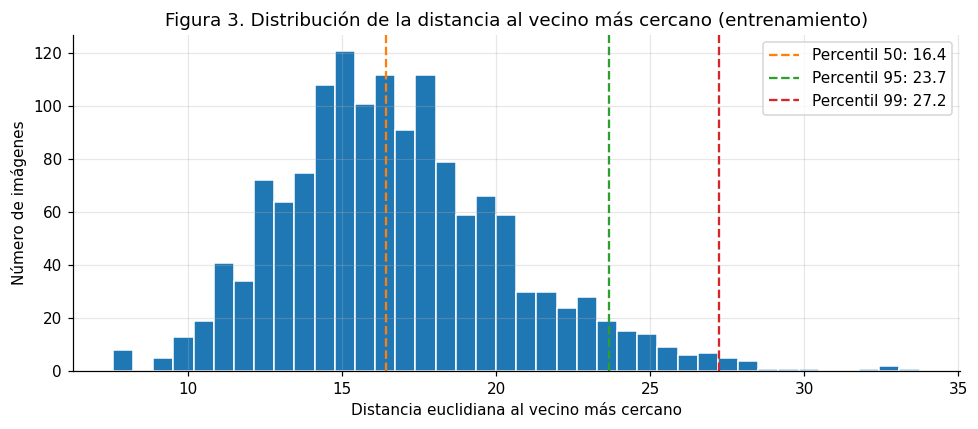

In [11]:
# Distancia de cada imagen de entrenamiento a su vecino más cercano (excluyéndose a sí misma)
nn = NearestNeighbors(n_neighbors=2, metric="euclidean").fit(X_train)
dist, _ = nn.kneighbors(X_train)
d_1nn = dist[:, 1]

percentiles = [0, 5, 25, 50, 75, 95, 99, 100]
display(pd.DataFrame({f"P{p}": [np.percentile(d_1nn, p)] for p in percentiles},
                     index=["Distancia al vecino más cercano"]).round(2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(d_1nn, bins=40, color="C0", edgecolor="white")
for p, c in [(50, "C1"), (95, "C2"), (99, "C3")]:
    v = np.percentile(d_1nn, p)
    ax.axvline(v, color=c, ls="--", label=f"Percentil {p}: {v:.1f}")
ax.set(xlabel="Distancia euclidiana al vecino más cercano",
       ylabel="Número de imágenes",
       title="Figura 3. Distribución de la distancia al vecino más cercano (entrenamiento)")
ax.legend()
fig.tight_layout()
fig.savefig("figuras/fig3_distancia_vecino_mas_cercano.png", bbox_inches="tight")
plt.show()

**Definición del rango de R (requisito 6).** La mitad de las imágenes tiene su vecino más cercano a menos de ≈ 16 unidades, y el 99 % a menos de ≈ 27. Por eso se define **R = 14, 15, …, 50** (paso 1):

- El extremo inferior (R = 14) está por debajo de la mediana: muchas imágenes quedarán sin vecinos y se verá el efecto de un radio demasiado pequeño.
- El extremo superior (R = 50) es casi el doble del percentil 99. Las bolas contienen cientos de ejemplos y se verá el efecto de un radio demasiado grande.

Un rango amplio permite ver la curva completa (subida, máximo y caída) y confirmar que el óptimo no está en un borde del rango.

### 6.2 Evaluación del rango de R con validación cruzada

Además de las 4 métricas, se registran dos métricas de diagnóstico con *scorers* personalizados:

- `sin_vecinos`: proporción de imágenes de validación sin ningún vecino dentro del radio.
- `vecinos_mediana`: mediana del número de vecinos dentro del radio.

In [12]:
valores_r = list(range(14, 51))

def crear_rnn(r):
    return RadiusNeighborsClassifier(
        radius=r,                     # radio R (hiperparámetro a seleccionar)
        weights="uniform",            # cada vecino dentro del radio vale un voto
        algorithm="auto",
        metric="minkowski",
        p=2,                          # distancia euclidiana, igual que en KNN
        outlier_label="most_frequent" # clase asignada si no hay vecinos en el radio
    )

# Scorers de diagnóstico (firma de scorer de sklearn: (estimador, X, y))
def _num_vecinos(est, X_val):
    vecinos = est.radius_neighbors(X_val, return_distance=False)
    return np.array([len(v) for v in vecinos])

def prop_sin_vecinos(est, X_val, y_val):
    return np.mean(_num_vecinos(est, X_val) == 0)

def mediana_vecinos(est, X_val, y_val):
    return np.median(_num_vecinos(est, X_val))

METRICAS_RNN = {**METRICAS, "sin_vecinos": prop_sin_vecinos,
                "vecinos_mediana": mediana_vecinos}

df_r = barrido_cv(crear_rnn, valores_r, "R", scoring=METRICAS_RNN)

tabla_r = df_r[["R"] + [f"{m}_media" for m in METRICAS]
               + ["f1_std", "sin_vecinos_media", "vecinos_mediana_media"]].copy()
tabla_r["sin_vecinos_media"] *= 100
tabla_r = tabla_r.rename(columns={"sin_vecinos_media": "% sin vecinos",
                                  "vecinos_mediana_media": "mediana vecinos"})
display(tabla_r.round(4))

,R,accuracy_media,precision_media,recall_media,f1_media,f1_std,% sin vecinos,mediana vecinos
0,14,0.2540,0.8870,0.2525,0.2652,0.0270,81.0009,0.000
1,15,0.3410,0.9134,0.3395,0.3790,0.0392,70.9778,0.000
2,16,0.4336,0.9152,0.4320,0.4848,0.0245,60.7492,0.000
3,17,0.5310,0.9178,0.5294,0.5866,0.0188,49.9634,0.250
4,18,0.6277,0.9215,0.6264,0.6835,0.0091,39.3166,1.000
5,19,0.7029,0.9255,0.7017,0.7504,0.0100,31.2448,1.500
6,20,0.7850,0.9306,0.7840,0.8176,0.0121,22.1994,2.250
7,21,0.8386,0.9373,0.8378,0.8620,0.0041,16.2833,3.250
8,22,0.8775,0.9439,0.8771,0.8925,0.0130,11.8978,4.250
9,23,0.9109,0.9513,0.9104,0.9197,0.0061,8.2803,6.000


### 6.3 Figura: métricas de desempeño en función de R

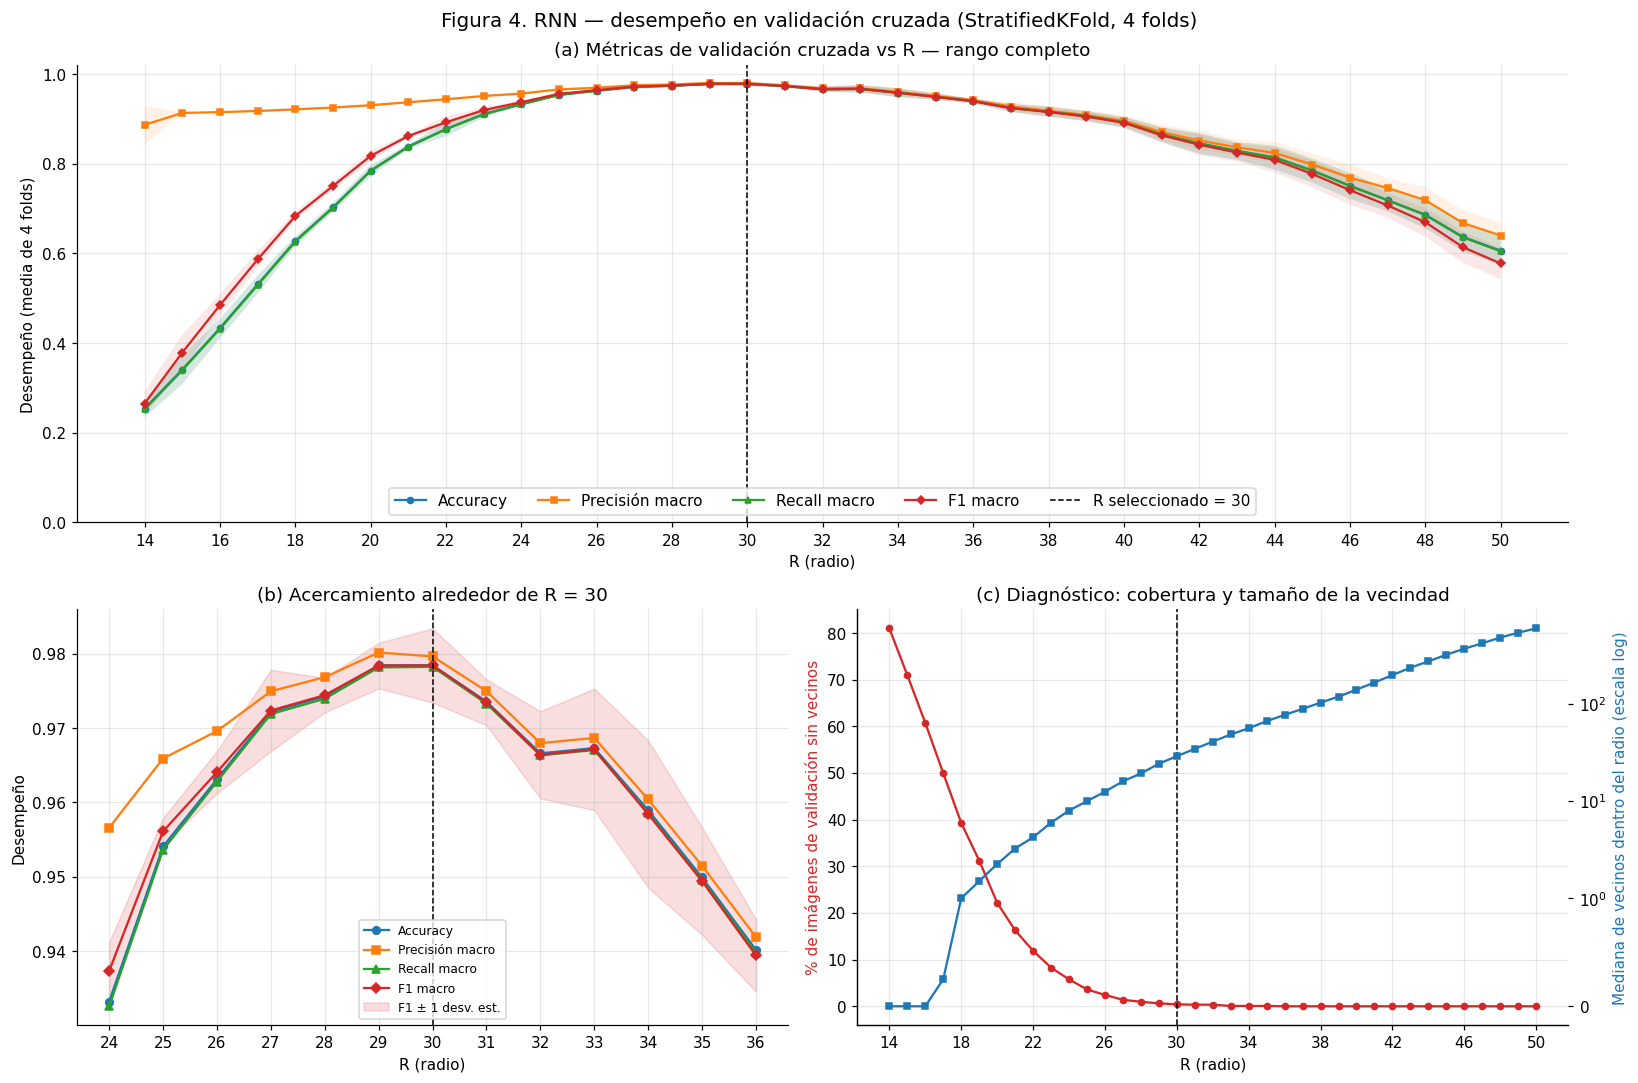

In [13]:
mejor_fila_r = seleccionar_mejor(df_r, "R")
mejor_r = float(mejor_fila_r["R"])

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1])
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# (a) Rango completo
for m in METRICAS:
    media, std = df_r[f"{m}_media"], df_r[f"{m}_std"]
    ax1.plot(df_r["R"], media, marker=marcadores[m], ms=4, label=NOMBRES[m])
    ax1.fill_between(df_r["R"], media - std, media + std, alpha=0.10)
ax1.axvline(mejor_r, color="k", ls="--", lw=1, label=f"R seleccionado = {mejor_r:g}")
ax1.set(xlabel="R (radio)", ylabel="Desempeño (media de 4 folds)",
        title="(a) Métricas de validación cruzada vs R — rango completo",
        xticks=valores_r[::2], ylim=(0, 1.02))
ax1.legend(loc="lower center", ncol=5)

# (b) Acercamiento a la zona del máximo
zona = df_r[(df_r["R"] >= mejor_r - 6) & (df_r["R"] <= mejor_r + 6)]
for m in METRICAS:
    ax2.plot(zona["R"], zona[f"{m}_media"], marker=marcadores[m], ms=5, label=NOMBRES[m])
ax2.fill_between(zona["R"], zona["f1_media"] - zona["f1_std"],
                 zona["f1_media"] + zona["f1_std"], alpha=0.15, color="C3",
                 label="F1 ± 1 desv. est.")
ax2.axvline(mejor_r, color="k", ls="--", lw=1)
ax2.set(xlabel="R (radio)", ylabel="Desempeño",
        title=f"(b) Acercamiento alrededor de R = {mejor_r:g}", xticks=list(zona["R"]))
ax2.legend(fontsize=8, loc="lower center")

# (c) Diagnóstico: imágenes sin vecinos y tamaño de la vecindad
ax3.plot(df_r["R"], 100 * df_r["sin_vecinos_media"], "o-", ms=4, color="C3",
         label="% de imágenes sin vecinos")
ax3.set_xlabel("R (radio)")
ax3.set_ylabel("% de imágenes de validación sin vecinos", color="C3")
ax3b = ax3.twinx()
ax3b.plot(df_r["R"], df_r["vecinos_mediana_media"], "s-", ms=4, color="C0",
          label="Mediana de vecinos")
ax3b.set_yscale("symlog", linthresh=1)
ax3b.set_ylabel("Mediana de vecinos dentro del radio (escala log)", color="C0")
ax3b.grid(False)
ax3.axvline(mejor_r, color="k", ls="--", lw=1)
ax3.set_title("(c) Diagnóstico: cobertura y tamaño de la vecindad")
ax3.set_xticks(valores_r[::4])

fig.suptitle("Figura 4. RNN — desempeño en validación cruzada (StratifiedKFold, 4 folds)",
             fontsize=13)
fig.tight_layout()
fig.savefig("figuras/fig4_rnn_metricas_vs_r.png", bbox_inches="tight")
plt.show()

**Lectura de la figura 4:**

- **Radios pequeños (R ≲ 22):** el panel (c) muestra que una gran parte de las imágenes de validación **no tiene ningún vecino** dentro del radio. Se les asigna la clase más frecuente, así que las métricas son muy bajas. La precisión macro queda por encima del recall en esa zona porque las clases predichas "de verdad", por votación, suelen ser correctas, pero muchas imágenes reales no se recuperan.
- **Zona óptima:** el desempeño sube rápido a medida que casi todas las imágenes encuentran vecinos, y alcanza su máximo cuando el porcentaje sin vecinos está cerca de cero y la vecindad contiene unas decenas de ejemplos.
- **Radios grandes (R ≳ 34):** ya no hay imágenes sin vecinos, pero la mediana de vecinos crece hacia cientos. La votación uniforme incluye muchos ejemplos de otras clases y el desempeño cae de forma sostenida.
- El óptimo queda **en el interior del rango** evaluado, lo que confirma que el rango fue adecuado.

### 6.4 Selección del mejor R (**requisito 7**)

In [14]:
print(f"R seleccionado (mayor F1 macro medio en CV): R = {mejor_r:g}\n")
display(mejor_fila_r[["R"] + [f"{m}_media" for m in METRICAS]
                     + [f"{m}_std" for m in METRICAS]
                     + ["sin_vecinos_media", "vecinos_mediana_media"]]
        .to_frame("RNN").T.round(4))

print("\nGanador según cada métrica por separado:")
display(mejor_por_metrica(df_r, "R"))

print("\nLos 5 mejores valores de R según F1 macro:")
display(df_r.sort_values(["f1_media", "accuracy_media"], ascending=False)
            .head(5)[["R", "accuracy_media", "precision_media", "recall_media",
                      "f1_media", "f1_std", "sin_vecinos_media"]].round(4))

R seleccionado (mayor F1 macro medio en CV): R = 30



,R,accuracy_media,precision_media,recall_media,f1_media,accuracy_std,precision_std,recall_std,f1_std,sin_vecinos_media,vecinos_mediana_media
RNN,30.0,0.9784,0.9796,0.9782,0.9784,0.0049,0.0048,0.0049,0.005,0.0042,29.0



Ganador según cada métrica por separado:


,R,Valor (media CV)
Accuracy,30.0,0.9784
Precisión macro,29.0,0.9802
Recall macro,30.0,0.9782
F1 macro,30.0,0.9784



Los 5 mejores valores de R según F1 macro:


,R,accuracy_media,precision_media,recall_media,f1_media,f1_std,sin_vecinos_media
16,30,0.9784,0.9796,0.9782,0.9784,0.0050,0.0042
15,29,0.9784,0.9802,0.9782,0.9784,0.0031,0.0063
14,28,0.9743,0.9768,0.9739,0.9744,0.0023,0.0097
17,31,0.9736,0.9750,0.9733,0.9734,0.0031,0.0035
13,27,0.9722,0.9749,0.9719,0.9724,0.0055,0.0139


**R seleccionado: R = 30** (F1 macro = 0.9784 ± 0.0050 en validación cruzada).

**Empate práctico entre R = 29 y R = 30.** Ambos radios tienen prácticamente las mismas métricas: la diferencia en F1 macro es ≈ 0.00002, menos que una sola imagen. Accuracy, recall y F1 favorecen por un margen mínimo a R = 30, mientras que la precisión favorece a R = 29. Se respeta el criterio definido de antemano (mayor F1 macro medio), que elige **R = 30**. Lo importante es que el óptimo es una **meseta** (R ≈ 29–30) y no un pico aislado, y que en R = 30 menos del 0.5 % de las imágenes de validación queda sin vecinos. El empate **no se rompe mirando el conjunto de prueba**, porque eso sería usar la prueba para elegir un hiperparámetro.

## 7. Evaluación final sobre el conjunto de prueba (20 %)

Con K\* y R\* ya fijados, cada modelo se **reentrena con todo el 80 % de entrenamiento** (1437 imágenes) y se evalúa **una sola vez** sobre las 360 imágenes de prueba, que no se usaron en ninguna decisión anterior. Estas cifras estiman el desempeño con datos nuevos.

In [15]:
def evaluar_en_prueba(modelo, nombre, parametro):
    y_pred = modelo.predict(X_test)
    return y_pred, {
        "Modelo": nombre,
        "Hiperparámetro": parametro,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precisión macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Errores": int((y_pred != y_test).sum()),
    }

knn_final = crear_knn(mejor_k).fit(X_train, y_train)
rnn_final = crear_rnn(mejor_r).fit(X_train, y_train)

y_pred_knn, res_knn = evaluar_en_prueba(knn_final, "KNN", f"K = {mejor_k}")
y_pred_rnn, res_rnn = evaluar_en_prueba(rnn_final, "RNN", f"R = {mejor_r:g}")

sin_vecinos_test = int((_num_vecinos(rnn_final, X_test) == 0).sum())
print(f"Imágenes de prueba sin vecinos dentro de R = {mejor_r:g}: "
      f"{sin_vecinos_test} de {len(X_test)}")

resultados_test = pd.DataFrame([res_knn, res_rnn]).set_index("Modelo")
display(resultados_test.round(4))

Imágenes de prueba sin vecinos dentro de R = 30: 0 de 360


,Hiperparámetro,Accuracy,Precisión macro,Recall macro,F1 macro,Errores
Modelo,,,,,,
KNN,K = 1,0.9861,0.9866,0.9859,0.9859,5
RNN,R = 30,0.9722,0.9734,0.9717,0.9716,10


### 7.1 Reporte por clase

In [16]:
print(f"==================  KNN (K = {mejor_k})  ==================")
print(classification_report(y_test, y_pred_knn, digits=4))
print(f"==================  RNN (R = {mejor_r:g})  ==================")
print(classification_report(y_test, y_pred_rnn, digits=4, zero_division=0))

==================  KNN (K = 1)  ==================
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9231    1.0000    0.9600        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    1.0000    1.0000        36
           7     1.0000    1.0000    1.0000        36
           8     0.9697    0.9143    0.9412        35
           9     1.0000    0.9444    0.9714        36

    accuracy                         0.9861       360
   macro avg     0.9866    0.9859    0.9859       360
weighted avg     0.9867    0.9861    0.9861       360

==================  RNN (R = 30)  ==================
              precision    recall  f1-score   support

           0     1.0000    0.9722    0.9859        36
           1     0.8780    

### 7.2 Matrices de confusión

Las filas son la clase real y las columnas la clase predicha. Los valores fuera de la diagonal son errores y muestran **qué dígitos se confunden entre sí**.

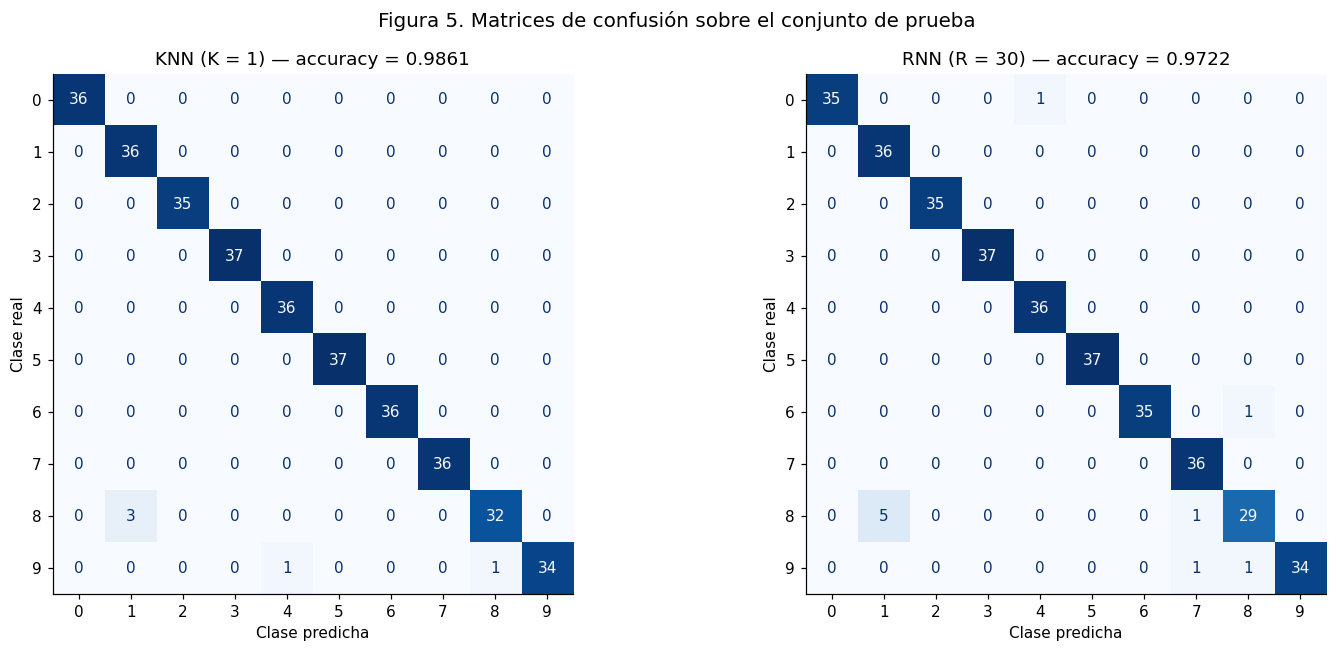

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, y_pred, titulo in [(axes[0], y_pred_knn, f"KNN (K = {mejor_k})"),
                           (axes[1], y_pred_rnn, f"RNN (R = {mejor_r:g})")]:
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=digits.target_names,
                                            cmap="Blues", colorbar=False, ax=ax)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{titulo} — accuracy = {acc:.4f}")
    ax.set_xlabel("Clase predicha"); ax.set_ylabel("Clase real"); ax.grid(False)
fig.suptitle("Figura 5. Matrices de confusión sobre el conjunto de prueba", fontsize=13)
fig.tight_layout()
fig.savefig("figuras/fig5_matrices_confusion.png", bbox_inches="tight")
plt.show()

### 7.3 ¿Qué imágenes se clasifican mal?

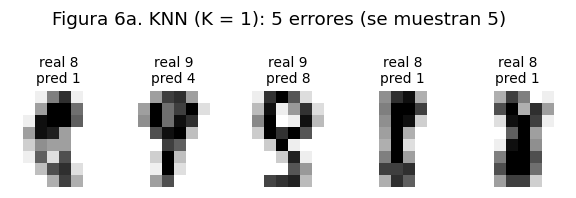

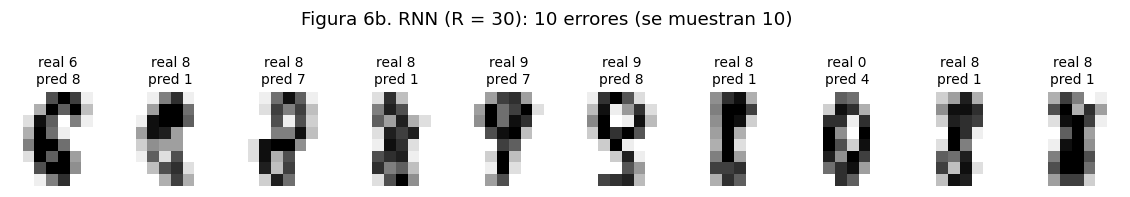

In [18]:
def mostrar_errores(y_pred, titulo, archivo, max_imgs=12):
    errores = np.where(y_pred != y_test)[0]
    if len(errores) == 0:
        print(f"{titulo}: sin errores en prueba.")
        return
    n = min(len(errores), max_imgs)
    fig, axes = plt.subplots(1, n, figsize=(1.3 * n, 2.0), squeeze=False)
    for ax, idx in zip(axes[0], errores[:n]):
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r", interpolation="nearest")
        ax.set_title(f"real {y_test[idx]}\npred {y_pred[idx]}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{titulo}: {len(errores)} errores (se muestran {n})", y=1.08)
    fig.savefig(archivo, bbox_inches="tight")
    plt.show()

mostrar_errores(y_pred_knn, f"Figura 6a. KNN (K = {mejor_k})", "figuras/fig6a_errores_knn.png")
mostrar_errores(y_pred_rnn, f"Figura 6b. RNN (R = {mejor_r:g})", "figuras/fig6b_errores_rnn.png")

A una resolución de 8 × 8 píxeles, varios de los errores son imágenes ambiguas incluso para una persona: trazos incompletos, dígitos inclinados, o 1/7, 3/9 y 8/1 con formas parecidas.

## 8. Comparación KNN vs RNN

Se compara lo estimado en validación cruzada (sobre el 80 %) con lo obtenido en prueba (20 %). Si ambas cifras son cercanas, la validación cruzada fue un buen estimador del desempeño con datos nuevos.

KNN con K = 1   |   RNN con R = 30


KNN                      RNN        
                CV (media ± std)  Prueba CV (media ± std)  Prueba
Accuracy         0.9896 ± 0.0036  0.9861  0.9784 ± 0.0049  0.9722
Precisión macro  0.9899 ± 0.0034  0.9866  0.9796 ± 0.0048  0.9734
Recall macro     0.9895 ± 0.0036  0.9859  0.9782 ± 0.0049  0.9717
F1 macro         0.9895 ± 0.0036  0.9859  0.9784 ± 0.0050  0.9716

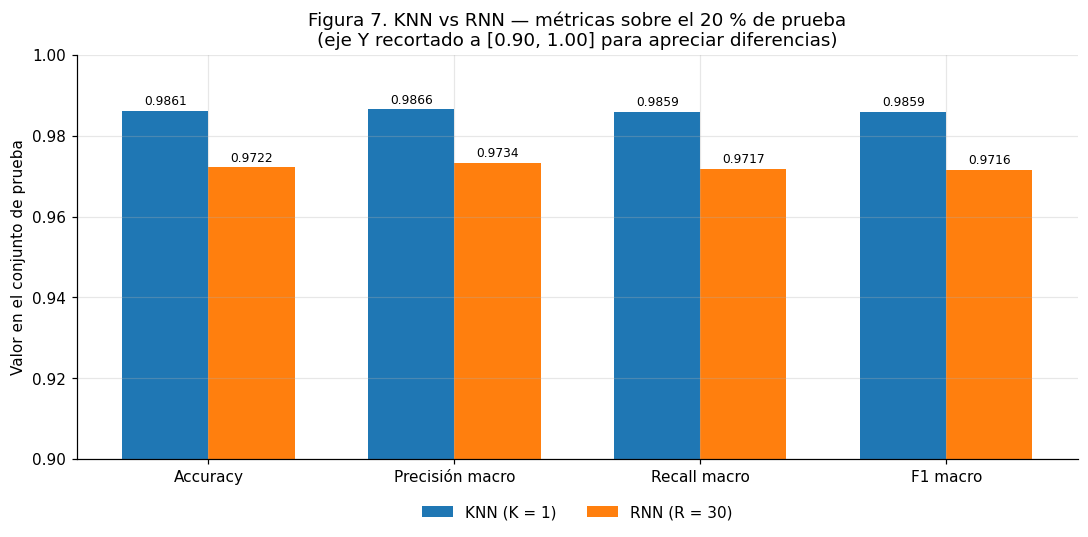

,Ambos aciertan,Solo KNN acierta,Solo RNN acierta,Ambos fallan
Muestras,350,5,0,5


In [19]:
comparacion = pd.DataFrame({
    ("KNN", "CV (media ± std)"): [f"{mejor_fila_k[f'{m}_media']:.4f} ± {mejor_fila_k[f'{m}_std']:.4f}" for m in METRICAS],
    ("KNN", "Prueba"):           [f"{res_knn[NOMBRES[m]]:.4f}" for m in METRICAS],
    ("RNN", "CV (media ± std)"): [f"{mejor_fila_r[f'{m}_media']:.4f} ± {mejor_fila_r[f'{m}_std']:.4f}" for m in METRICAS],
    ("RNN", "Prueba"):           [f"{res_rnn[NOMBRES[m]]:.4f}" for m in METRICAS],
}, index=[NOMBRES[m] for m in METRICAS])
comparacion.columns = pd.MultiIndex.from_tuples(comparacion.columns)
print(f"KNN con K = {mejor_k}   |   RNN con R = {mejor_r:g}")
display(comparacion)

# Figura 7: barras agrupadas de las métricas de prueba
fig, ax = plt.subplots(figsize=(10, 5))
metricas_graf = [NOMBRES[m] for m in METRICAS]
x = np.arange(len(metricas_graf)); ancho = 0.35
for i, (res, etiqueta) in enumerate([(res_knn, f"KNN (K = {mejor_k})"),
                                     (res_rnn, f"RNN (R = {mejor_r:g})")]):
    vals = [res[m] for m in metricas_graf]
    barras = ax.bar(x + (i - 0.5) * ancho, vals, ancho, label=etiqueta)
    ax.bar_label(barras, fmt="%.4f", fontsize=8, padding=2)
ax.set_xticks(x, metricas_graf)
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("Valor en el conjunto de prueba")
ax.set_title("Figura 7. KNN vs RNN — métricas sobre el 20 % de prueba\n"
             "(eje Y recortado a [0.90, 1.00] para apreciar diferencias)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig("figuras/fig7_comparacion_knn_rnn.png", bbox_inches="tight")
plt.show()

# Coincidencias muestra a muestra
acierto_knn, acierto_rnn = y_pred_knn == y_test, y_pred_rnn == y_test
display(pd.DataFrame({"Muestras": {
    "Ambos aciertan": int(np.sum(acierto_knn & acierto_rnn)),
    "Solo KNN acierta": int(np.sum(acierto_knn & ~acierto_rnn)),
    "Solo RNN acierta": int(np.sum(~acierto_knn & acierto_rnn)),
    "Ambos fallan": int(np.sum(~acierto_knn & ~acierto_rnn)),
}}).T)

## 9. Conclusiones

1. **Cumplimiento del procedimiento.** Se usó el dataset `digits`, una partición estratificada 80/20 y validación cruzada `StratifiedKFold` con 4 folds sobre el entrenamiento. Se evaluaron rangos de **K (1–30)** y **R (14–50)** con cuatro métricas (accuracy, precisión, recall y F1 macro) y se graficaron. K y R se eligieron con un criterio explícito (mayor F1 macro medio, desempate por accuracy). El conjunto de prueba se usó **solo al final**.
2. **KNN.** El mejor desempeño se obtiene con **K pequeño**. En este dataset las imágenes de un mismo dígito forman grupos compactos en el espacio de 64 dimensiones, así que el vecino más cercano casi siempre es de la misma clase. Al aumentar K entran vecinos de dígitos parecidos y el desempeño baja de forma gradual.
3. **RNN.** R tiene un **óptimo interior** que surge de dos efectos opuestos, visibles en la figura 4c. Con radios pequeños muchas imágenes quedan sin vecinos. Con radios grandes cada bola contiene cientos de ejemplos de varias clases y el voto uniforme se diluye. Elegir R exige conocer la escala de las distancias (figura 3), algo que no hace falta con K.
4. **Comparación.** Ambos clasificadores superan el 97 % en todas las métricas de prueba. KNN (K = 1) comete 5 errores de 360 y RNN (R = 30) comete 10. Todos los aciertos de RNN también los consigue KNN, y los dígitos más difíciles para ambos son el 8 y el 1. **KNN resulta un poco superior y más fácil de ajustar**: garantiza exactamente K vecinos para cualquier imagen, mientras que RNN adapta el número de vecinos a la densidad local, lo que en `digits` no aporta ventaja. En un conjunto con densidades muy distintas entre regiones o con valores atípicos que convenga detectar, RNN podría ser preferible.
5. **Validez de la estimación.** Las métricas de prueba quedan cerca de las estimadas por validación cruzada. Son ligeramente inferiores (≈ 0.4 puntos porcentuales en KNN y ≈ 0.7 en RNN), lo cual es esperable al medir con 360 imágenes nuevas: cada imagen equivale a 0.28 puntos. Esto indica que la selección de hiperparámetros no sobreajustó las particiones de validación.

Las cifras exactas de esta ejecución están en las tablas de las secciones 5.3, 6.4, 7 y 8, y la siguiente celda las resume.

In [20]:
print("=" * 64)
print("RESUMEN DEL TALLER 07")
print("=" * 64)
print(f"Partición: {len(X_train)} entrenamiento / {len(X_test)} prueba (80/20, estratificada)")
print(f"Validación cruzada: StratifiedKFold con {N_FOLDS} folds, semilla {SEMILLA}")
print(f"Rango de K evaluado: {valores_k[0]}–{valores_k[-1]}   |   Rango de R evaluado: {valores_r[0]}–{valores_r[-1]}")
print("-" * 64)
print(f"KNN  K* = {mejor_k:<4g}  F1 CV = {mejor_fila_k['f1_media']:.4f} ± {mejor_fila_k['f1_std']:.4f}"
      f"   |  Prueba: acc = {res_knn['Accuracy']:.4f}, F1 = {res_knn['F1 macro']:.4f}")
print(f"RNN  R* = {mejor_r:<4g}  F1 CV = {mejor_fila_r['f1_media']:.4f} ± {mejor_fila_r['f1_std']:.4f}"
      f"   |  Prueba: acc = {res_rnn['Accuracy']:.4f}, F1 = {res_rnn['F1 macro']:.4f}")
print("=" * 64)

RESUMEN DEL TALLER 07
Partición: 1437 entrenamiento / 360 prueba (80/20, estratificada)
Validación cruzada: StratifiedKFold con 4 folds, semilla 42
Rango de K evaluado: 1–30   |   Rango de R evaluado: 14–50
----------------------------------------------------------------
KNN  K* = 1     F1 CV = 0.9895 ± 0.0036   |  Prueba: acc = 0.9861, F1 = 0.9859
RNN  R* = 30    F1 CV = 0.9784 ± 0.0050   |  Prueba: acc = 0.9722, F1 = 0.9716


---
## Anexo A. Verificaciones adicionales

### A.1 Comprobación con `GridSearchCV`

En clase se usó `GridSearchCV` para buscar hiperparámetros. Aquí se repite la búsqueda con esa herramienta, **usando los mismos 4 folds y el mismo criterio (F1 macro)**, para confirmar que da el mismo K\* y R\* que el barrido manual.

In [21]:
gs_knn = GridSearchCV(crear_knn(1), {"n_neighbors": valores_k}, cv=cv,
                      scoring=METRICAS, refit="f1", n_jobs=-1).fit(X_train, y_train)
gs_rnn = GridSearchCV(crear_rnn(30), {"radius": valores_r}, cv=cv,
                      scoring=METRICAS, refit="f1", n_jobs=-1).fit(X_train, y_train)

print(f"GridSearchCV KNN → {gs_knn.best_params_}, F1 = {gs_knn.best_score_:.4f}  "
      f"(barrido manual: K = {mejor_k})")
print(f"GridSearchCV RNN → {gs_rnn.best_params_}, F1 = {gs_rnn.best_score_:.4f}  "
      f"(barrido manual: R = {mejor_r:g})")
assert gs_knn.best_params_["n_neighbors"] == mejor_k
assert gs_rnn.best_params_["radius"] == mejor_r
print("✔ Ambos métodos coinciden.")

GridSearchCV KNN → {'n_neighbors': 1}, F1 = 0.9895  (barrido manual: K = 1)
GridSearchCV RNN → {'radius': 30}, F1 = 0.9784  (barrido manual: R = 30)
✔ Ambos métodos coinciden.


### A.2 ¿Habría ayudado estandarizar?

En la sección 2 se argumentó que no conviene estandarizar los píxeles. Aquí se comprueba con los mismos 4 folds, colocando `StandardScaler` **dentro de un `Pipeline`**. Así el escalador se ajusta solo con los folds de entrenamiento de cada iteración y no hay fuga de datos.

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

filas = []
for nombre, modelo in [(f"KNN K={mejor_k} sin escalar", crear_knn(mejor_k)),
                       (f"KNN K={mejor_k} con StandardScaler",
                        make_pipeline(StandardScaler(), crear_knn(mejor_k)))]:
    r = cross_validate(modelo, X_train, y_train, cv=cv, scoring=METRICAS, n_jobs=-1)
    filas.append({"Configuración": nombre,
                  "Accuracy": r["test_accuracy"].mean(),
                  "F1 macro": r["test_f1"].mean(),
                  "F1 std": r["test_f1"].std()})
display(pd.DataFrame(filas).set_index("Configuración").round(4))

,Accuracy,F1 macro,F1 std
Configuración,,,
KNN K=1 sin escalar,0.9896,0.9895,0.0036
KNN K=1 con StandardScaler,0.9687,0.9685,0.0085


La estandarización **no mejora** el desempeño, y en este caso lo empeora. Esto confirma la decisión de trabajar con los píxeles en su escala original. (Para RNN, además, estandarizar cambiaría por completo la escala de las distancias, y el rango de R tendría que redefinirse).

### A.3 Pesos por distancia (`weights="distance"`)

El enunciado pide seleccionar K y R. Como exploración adicional, se muestra el efecto de ponderar cada voto por el inverso de la distancia. Así, los vecinos más cercanos pesan más.

In [23]:
filas = []
for w in ["uniform", "distance"]:
    for tipo, modelo in [
        (f"KNN K={mejor_k}", KNeighborsClassifier(n_neighbors=mejor_k, weights=w)),
        (f"RNN R={mejor_r:g}", RadiusNeighborsClassifier(radius=mejor_r, weights=w,
                                                          outlier_label="most_frequent")),
    ]:
        r = cross_validate(modelo, X_train, y_train, cv=cv, scoring=METRICAS, n_jobs=-1)
        filas.append({"Modelo": tipo, "weights": w,
                      "Accuracy": r["test_accuracy"].mean(), "F1 macro": r["test_f1"].mean()})
display(pd.DataFrame(filas).set_index(["Modelo", "weights"]).round(4))

,,Accuracy,F1 macro
Modelo,weights,,
KNN K=1,uniform,0.9896,0.9895
RNN R=30,uniform,0.9784,0.9784
KNN K=1,distance,0.9896,0.9895
RNN R=30,distance,0.9798,0.9798


Con K = 1 los pesos no importan, porque solo vota un vecino. En RNN, ponderar por distancia mejora un poco el resultado: suaviza la dilución del voto cuando la bola contiene muchos ejemplos. Es una posible mejora para trabajos futuros. No cambia la selección de R pedida en el taller, que se hizo con votación uniforme para que la comparación con KNN fuera en igualdad de condiciones.

---
## Referencias

- Documentación de scikit-learn: [`load_digits`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html), [`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), [`RadiusNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.RadiusNeighborsClassifier.html), [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html), [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html), [Nearest Neighbors — guía de usuario](https://scikit-learn.org/stable/modules/neighbors.html).
- Alpaydin, E. y Kaynak, C. (1998). *Optical Recognition of Handwritten Digits* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C50P49
- Zurek, E. Ejemplos del curso Inteligencia Artificial, repositorio [eduardozurek/ia](https://github.com/eduardozurek/ia) (`_007_aprendizaje_supervisado`).
- Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.), cap. 13: *Prototype Methods and Nearest-Neighbors*. Springer.